In [1]:
#load data
import pandas as pd

df = pd.read_csv('HousePricePrediction.csv')

In [3]:
df.shape

(2919, 13)

In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [5]:
df.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [6]:
#data preprocessing - data cleaning

#remove Id as it does not contribute
df.drop(['Id'], axis=1,inplace=True)

#replace SalePrice empty values with their mean values
df['SalePrice'] = df['SalePrice'].fillna(df['SalePrice'].mean())

#drop records with null values
df = df.dropna()

df.isnull().sum()





MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [7]:
#data preprocessing - encoding

cols = ['MSZoning', 'LotConfig','BldgType','Exterior1st']
df = pd.get_dummies(df, columns=cols,drop_first=True)

In [9]:
#train test split

from sklearn.model_selection import train_test_split

X = df.drop(['SalePrice'], axis = 1)
y = df['SalePrice']

X_train,X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 0)

In [10]:
X_train.head()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
1453,20,17217,5,2006,2006,0.0,1140.0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2021,20,19508,5,1974,1974,0.0,1430.0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
188,90,7018,5,1979,1979,0.0,1086.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1273,80,11512,7,1959,2006,0.0,1019.0,False,False,True,...,False,False,False,False,True,False,False,False,False,False
1960,20,7560,5,1971,1971,613.0,864.0,False,False,True,...,False,False,False,True,False,False,False,False,False,False


In [11]:
#Train Linear Regression Model


from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
#Model Evaluation
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))
print(mean_absolute_percentage_error(y_test, y_pred))

R2 Score: 0.37414217961383156
MAE: 30829.93666432242
RMSE: 41138.558702301765
0.18742025463428386


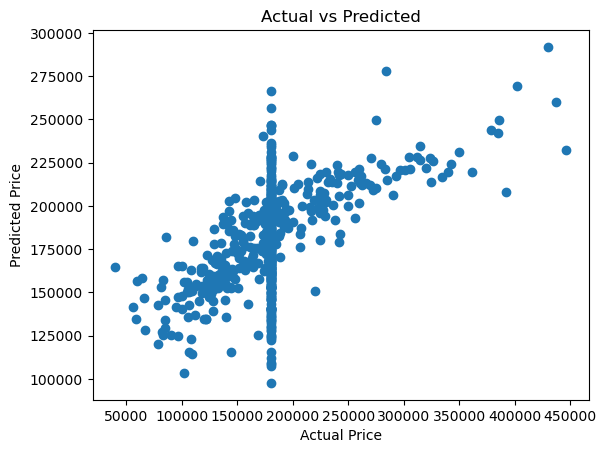

In [16]:
#visualize
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

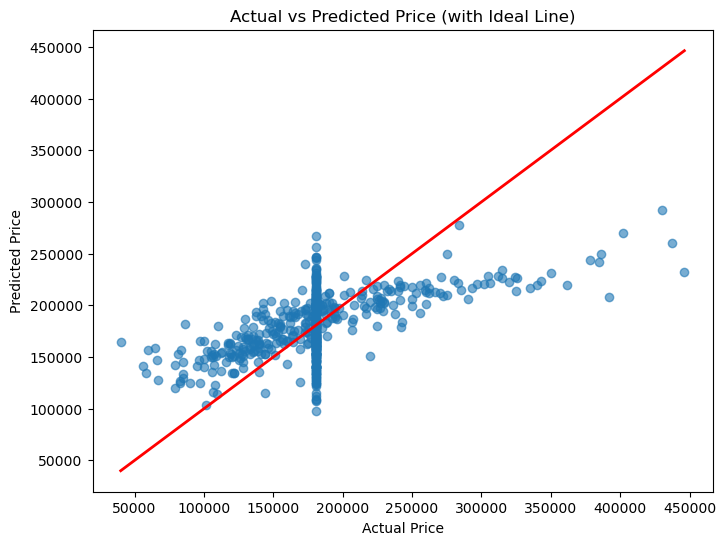

In [17]:
#actual vs predicted with ideal line
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# ideal line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (with Ideal Line)")

plt.show()

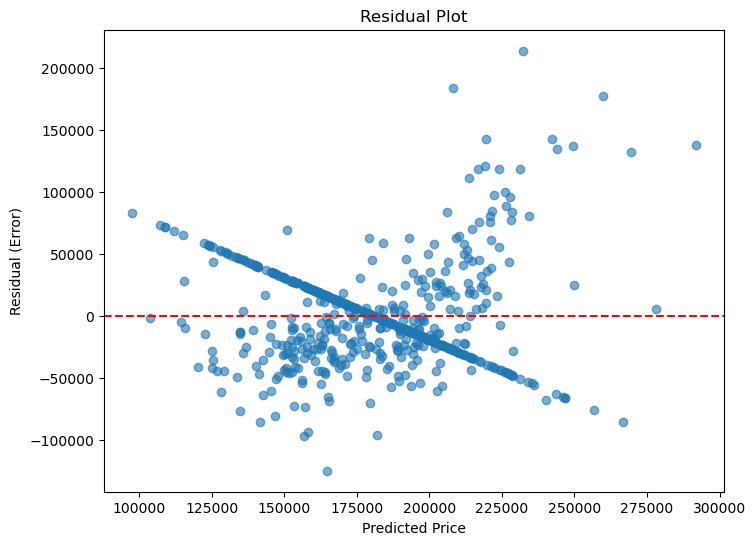

In [18]:
#residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot")

plt.show()